# Advanced 1: String Surgery - Text Processing for Digital Twins

## Learning Objectives
- Master Python string manipulation techniques
- Learn text cleaning and preprocessing for RAG systems
- Build robust text processing pipelines
- Debug and slice text effectively

## Key Insight
> **(Logic Bridge) Before using LangChain, learn to manually split() text. If you can't slice a string, you can't debug RAG.**

## Digital Twin Context
Your digital twin needs to process messy, real-world text:
- User messages with typos and inconsistent formatting
- Documents from various sources (PDFs, emails, chats)
- Structured data extraction from unstructured text
- Context preparation for LLM consumption

This is the **foundation** for building RAG systems!

In [1]:
# Import required libraries
import re
import string
from typing import List, Dict, Tuple
from collections import Counter
import json

print("✅ String surgery tools loaded!")
print("\n🔧 Available string methods:")
print([m for m in dir(str) if not m.startswith('_')][:15], "...")

✅ String surgery tools loaded!

🔧 Available string methods:
['capitalize', 'casefold', 'center', 'count', 'encode', 'endswith', 'expandtabs', 'find', 'format', 'format_map', 'index', 'isalnum', 'isalpha', 'isascii', 'isdecimal'] ...


---
## Part 1: Basic String Operations - The Fundamentals

Before building complex systems, master the basics!

### 1.1 String Slicing and Indexing

In [2]:
# Digital twin user message
user_message = "Hello! I love running at 6am every morning. Coffee is essential."

print("Original message:")
print(f"  '{user_message}'")
print(f"  Length: {len(user_message)} characters")

# Basic indexing
print("\n📍 Indexing:")
print(f"  First character: '{user_message[0]}'")
print(f"  Last character: '{user_message[-1]}'")
print(f"  Character at position 10: '{user_message[10]}'")

# Slicing
print("\n✂️ Slicing:")
print(f"  First 5 characters: '{user_message[:5]}'")
print(f"  Last 10 characters: '{user_message[-10:]}'")
print(f"  Middle section (7-20): '{user_message[7:20]}'")
print(f"  Every 2nd character: '{user_message[::2]}'")
print(f"  Reversed: '{user_message[::-1]}'")

Original message:
  'Hello! I love running at 6am every morning. Coffee is essential.'
  Length: 64 characters

📍 Indexing:
  First character: 'H'
  Last character: '.'
  Character at position 10: 'o'

✂️ Slicing:
  First 5 characters: 'Hello'
  Last 10 characters: 'essential.'
  Middle section (7-20): 'I love runnin'
  Every 2nd character: 'Hlo  oerniga a vr onn.Cfe sesnil'
  Reversed: '.laitnesse si eeffoC .gninrom yreve ma6 ta gninnur evol I !olleH'


### 🎯 Exercise 1.1 (Easy): String Extraction

**Task**: Extract specific information from a digital twin log entry.

Given: `"2026-01-13 14:30:00 | USER_123 | Activity: Running | Duration: 45min"`

Extract:
1. The date (YYYY-MM-DD)
2. The time (HH:MM:SS)
3. The user ID
4. The activity
5. The duration

In [3]:
# YOUR CODE HERE
log_entry = "2026-01-13 14:30:00 | USER_123 | Activity: Running | Duration: 45min"
print(log_entry)
print(f"Length: {len(log_entry)} characters")

# Extract each component using slicing
date = log_entry[0:10]  # Example
time = log_entry[11:19]
user_id = log_entry[21:30]
activity = log_entry[42:50]
duration = log_entry[63:68]

# Verify your extraction
print(f"Date: {date}")
print(f"Time: {time}")
print(f"User ID: {user_id}")
print(f"Activity: {activity}")
print(f"Duration: {duration}")

2026-01-13 14:30:00 | USER_123 | Activity: Running | Duration: 45min
Length: 68 characters
Date: 2026-01-13
Time: 14:30:00
User ID:  USER_123
Activity:  Running
Duration: 45min


### 1.2 String Methods - Your Power Tools

In [4]:
# Messy user input (real-world scenario)
messy_input = "  I LOVE running, Coding AND   reading!!!  "

print("Original (messy):")
print(f"  '{messy_input}'")

# Cleaning operations
print("\n🧹 Cleaning operations:")

# Strip whitespace
cleaned = messy_input.strip()
print(f"  .strip(): '{cleaned}'")

# Case normalization
print(f"  .lower(): '{cleaned.lower()}'")
print(f"  .upper(): '{cleaned.upper()}'")
print(f"  .title(): '{cleaned.title()}'")

# Replace
print(f"  .replace('!', ''): '{cleaned.replace('!', '')}'")

# Split
words = cleaned.lower().replace('!', '').replace(',', '').split()
print(f"  .split(): {words}")

# Join
rejoined = " ".join(words)
print(f"  ' '.join(): '{rejoined}'")

Original (messy):
  '  I LOVE running, Coding AND   reading!!!  '

🧹 Cleaning operations:
  .strip(): 'I LOVE running, Coding AND   reading!!!'
  .lower(): 'i love running, coding and   reading!!!'
  .upper(): 'I LOVE RUNNING, CODING AND   READING!!!'
  .title(): 'I Love Running, Coding And   Reading!!!'
  .replace('!', ''): 'I LOVE running, Coding AND   reading'
  .split(): ['i', 'love', 'running', 'coding', 'and', 'reading']
  ' '.join(): 'i love running coding and reading'


### 1.3 Searching and Finding

In [5]:
text = "I love running at 6am. Running keeps me energized."

print("Text:", text)
print("\n🔍 Searching operations:")

# Find
print(f"  .find('running'): {text.find('running')}  # Position of first occurrence")
print(f"  .find('Running'): {text.find('Running')}")
print(f"  .find('swimming'): {text.find('swimming')}  # Returns -1 if not found")

# Count
print(f"\n  .count('running'): {text.count('running')}")
print(f"  .count('Running'): {text.count('Running')}")
print(f"  .lower().count('running'): {text.lower().count('running')}  # Case-insensitive")

# Boolean checks
print("\n  Boolean checks:")
print(f"    'running' in text: {'running' in text}")
print(f"    'Running' in text: {'Running' in text}")
print(f"    text.startswith('I love'): {text.startswith('I love')}")
print(f"    text.endswith('energized.'): {text.endswith('energized.')}")

Text: I love running at 6am. Running keeps me energized.

🔍 Searching operations:
  .find('running'): 7  # Position of first occurrence
  .find('Running'): 23
  .find('swimming'): -1  # Returns -1 if not found

  .count('running'): 1
  .count('Running'): 1
  .lower().count('running'): 2  # Case-insensitive

  Boolean checks:
    'running' in text: True
    'Running' in text: True
    text.startswith('I love'): True
    text.endswith('energized.'): True


### 🎯 Exercise 1.2 (Easy): Text Cleaning Pipeline

**Task**: Create a function to clean user input for the digital twin.

**Requirements**:
1. Remove extra whitespace
2. Convert to lowercase
3. Remove punctuation
4. Remove stop words (common words like 'the', 'a', 'is')

In [6]:
# YOUR CODE HERE
def clean_text(text: str, remove_stopwords: bool = True) -> str:
    """
    Clean text for digital twin processing.

    Args:
        text: Input text
        remove_stopwords: Whether to remove common words

    Returns:
        str: Cleaned text
    """
    # Define stopwords
    stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were',
                 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}

    # Step 1: Strip whitespace
    cleaned = text.strip()

    # Step 2: Convert to lowercase
    cleaned = cleaned.lower()

    # Step 3: Remove punctuation
    translator = str.maketrans('', '', string.punctuation)
    cleaned = cleaned.translate(translator)
    #cleaned = cleaned.replace('!', '').replace('.', '')

    # Step 4: Remove stopwords (if enabled)
    if remove_stopwords:
        words = cleaned.split()
        cleaned = ' '.join([word for word in words if word not in stopwords])

    return cleaned

# Test your function
test_texts = [
    "  I LOVE running in the morning!  ",
    "The weather is perfect for outdoor activities.",
    "Coffee, coding, and creativity are my passions!!!"
]

for text in test_texts:
    cleaned = clean_text(text)
    print(f"Original: '{text}'")
    print(f"Cleaned:  '{cleaned}'")
    print()

Original: '  I LOVE running in the morning!  '
Cleaned:  'i love running morning'

Original: 'The weather is perfect for outdoor activities.'
Cleaned:  'weather perfect outdoor activities'

Original: 'Coffee, coding, and creativity are my passions!!!'
Cleaned:  'coffee coding creativity my passions'



---
## Part 2: Regular Expressions - Pattern Matching Power

When basic string methods aren't enough, regex is your weapon!

### 2.1 Regex Basics

In [7]:
# Digital twin conversation with multiple data types
conversation = """
User: My email is john.doe@email.com and I live at 123 Main St.
User: Call me at +1-555-123-4567 or text me!
User: I usually wake up at 6:30am and sleep by 10:45pm.
User: Check out my profile: https://example.com/profile/johndoe
"""

print("Conversation:")
print(conversation)
print("\n" + "="*60)

# Extract emails
email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
emails = re.findall(email_pattern, conversation)
print(f"\n📧 Emails found: {emails}")

# Extract phone numbers
phone_pattern = r'\+?\d{1,3}[-.]?\d{3}[-.]?\d{3}[-.]?\d{4}'
phones = re.findall(phone_pattern, conversation)
print(f"📱 Phone numbers found: {phones}")

# Extract times
time_pattern = r'\d{1,2}:\d{2}(?:am|pm)'
times = re.findall(time_pattern, conversation)
print(f"🕐 Times found: {times}")

# Extract URLs
url_pattern = r'https?://[^\s]+'
urls = re.findall(url_pattern, conversation)
print(f"🔗 URLs found: {urls}")

Conversation:

User: My email is john.doe@email.com and I live at 123 Main St.
User: Call me at +1-555-123-4567 or text me!
User: I usually wake up at 6:30am and sleep by 10:45pm.
User: Check out my profile: https://example.com/profile/johndoe



📧 Emails found: ['john.doe@email.com']
📱 Phone numbers found: ['+1-555-123-4567']
🕐 Times found: ['6:30am', '10:45pm']
🔗 URLs found: ['https://example.com/profile/johndoe']


### 2.2 Common Regex Patterns for Digital Twins

In [8]:
# Pattern library for digital twin data extraction
PATTERNS = {
    'email': r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
    'phone': r'\+?\d{1,3}[-.]?\d{3}[-.]?\d{3}[-.]?\d{4}',
    'date': r'\d{4}-\d{2}-\d{2}',
    'time': r'\d{1,2}:\d{2}(?::\d{2})?(?:am|pm)?',
    'url': r'https?://[^\s]+',
    'hashtag': r'#\w+',
    'mention': r'@\w+',
    'number': r'\b\d+(?:\.\d+)?\b',
    'duration': r'\d+(?:h|hr|hours?|m|min|minutes?|s|sec|seconds?)',
}

def extract_patterns(text: str, pattern_name: str) -> List[str]:
    """
    Extract all matches for a given pattern.

    Args:
        text: Input text
        pattern_name: Name of pattern from PATTERNS dict

    Returns:
        list: All matches
    """
    if pattern_name not in PATTERNS:
        raise ValueError(f"Unknown pattern: {pattern_name}")

    pattern = PATTERNS[pattern_name]
    return re.findall(pattern, text, re.IGNORECASE)

# Test with social media-like text
social_text = """
Just finished a 5km run in 30min! 🏃 #running #fitness
@FitnessCoach check out my progress at https://myapp.com/progress
Next goal: 10km in under 1hr. Training starts 2026-01-15 at 6:00am!
"""

print("Text:", social_text)
print("\n" + "="*60)
print("\nExtracted data:")

for pattern_name in ['number', 'duration', 'hashtag', 'mention', 'url', 'date', 'time']:
    matches = extract_patterns(social_text, pattern_name)
    if matches:
        print(f"  {pattern_name.title()}: {matches}")

Text: 
Just finished a 5km run in 30min! 🏃 #running #fitness
@FitnessCoach check out my progress at https://myapp.com/progress
Next goal: 10km in under 1hr. Training starts 2026-01-15 at 6:00am!



Extracted data:
  Number: ['2026', '01', '15', '6']
  Duration: ['30m', '1h']
  Hashtag: ['#running', '#fitness']
  Mention: ['@FitnessCoach']
  Url: ['https://myapp.com/progress']
  Date: ['2026-01-15']
  Time: ['6:00am']


### 🎯 Exercise 2.1 (Intermediate): Build a Personal Data Extractor

**Task**: Create a comprehensive data extraction system for digital twin profiles.

**Requirements**:
1. Extract all personal identifiers (email, phone, social handles)
2. Extract temporal information (dates, times, durations)
3. Extract preferences and activities from hashtags
4. Return structured data (dictionary)

In [9]:
# YOUR CODE HERE
def extract_profile_data(text: str) -> Dict[str, any]:
    """
    Extract structured data from user text.

    Args:
        text: User profile or conversation text

    Returns:
        dict: Extracted data organized by category
    """
    profile = {
        'contact': {},
        'temporal': {},
        'interests': {},
        'metrics': {},
    }

    # Extract contact information
    contact = {
        'email': extract_patterns(test_profile, 'email'),
        'phone': extract_patterns(test_profile, 'phone'),
        'social': extract_patterns(test_profile, 'mention')
    }

    # Extract temporal data
    temporal = {
        'date': extract_patterns(test_profile, 'date'),
        'time': extract_patterns(test_profile, 'time'),
        'duration': extract_patterns(test_profile, 'duration')
    }

    # Extract interests from hashtags
    interests = {
        'hasgtag': extract_patterns(test_profile, 'hashtag')
    }

    # Extract numerical metrics
    metrics = {
        'number': extract_patterns(test_profile, 'number'),
        'duration': extract_patterns(test_profile, 'duration')
    }

    # Organize extracted data
    profile['contact'] = contact
    profile['temporal'] = temporal
    profile['interests'] = interests
    profile['metrics'] = metrics

    return profile

# Test with comprehensive profile
test_profile = """
Hi! I'm Sarah (sarah.runner@email.com). Reach me at +1-555-234-5678.
I run 5km daily at 6:30am and love #running #fitness #health.
My best time: 25min for 5km. Goal: 10km in 50min by 2026-03-01.
Follow my journey: https://strava.com/sarah_runs and @SarahRuns on Twitter!
"""

extracted = extract_profile_data(test_profile)
print(json.dumps(extracted, indent=2))

{
  "contact": {
    "email": [
      "sarah.runner@email.com"
    ],
    "phone": [
      "+1-555-234-5678"
    ],
    "social": [
      "@email",
      "@SarahRuns"
    ]
  },
  "temporal": {
    "date": [
      "2026-03-01"
    ],
    "time": [
      "6:30am"
    ],
    "duration": [
      "25m",
      "50m"
    ]
  },
  "interests": {
    "hasgtag": [
      "#running",
      "#fitness",
      "#health"
    ]
  },
  "metrics": {
    "number": [
      "1",
      "555",
      "234",
      "5678",
      "6",
      "2026",
      "03",
      "01"
    ],
    "duration": [
      "25m",
      "50m"
    ]
  }
}


In [18]:
contact = {
    'email': extract_patterns(test_profile, 'email'),
    'phone': extract_patterns(test_profile, 'phone'),
    'social': extract_patterns(test_profile, 'mention')
}
print(contact)

{'email': ['sarah.runner@email.com'], 'phone': ['+1-555-234-5678'], 'social': ['@email', '@SarahRuns']}


---
## Part 3: Text Chunking for RAG Systems

**Critical for RAG**: Breaking documents into optimal chunks for retrieval.

### 3.1 Simple Chunking Strategies

In [10]:
# Sample document about digital twin
long_document = """
A digital twin is a virtual representation of a physical object or system.
Digital twins are used across various industries. In healthcare, they model patient health.
In manufacturing, they simulate production processes. Smart cities use digital twins for urban planning.

The technology relies on real-time data from sensors. This data feeds into simulation models.
Machine learning algorithms analyze patterns. Predictions help optimize operations.

Benefits include improved decision-making. Companies reduce costs through predictive maintenance.
Healthcare providers personalize treatments. City planners optimize resource allocation.
"""

def chunk_by_sentences(text: str, sentences_per_chunk: int = 2) -> List[str]:
    """
    Chunk text by sentences.

    Args:
        text: Input text
        sentences_per_chunk: Number of sentences per chunk

    Returns:
        list: Text chunks
    """
    # Simple sentence splitting (not perfect, but educational)
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = ' '.join(sentences[i:i+sentences_per_chunk])
        chunks.append(chunk)

    return chunks

def chunk_by_words(text: str, words_per_chunk: int = 50, overlap: int = 10) -> List[str]:
    """
    Chunk text by word count with overlap.

    Args:
        text: Input text
        words_per_chunk: Target words per chunk
        overlap: Number of overlapping words

    Returns:
        list: Text chunks
    """
    words = text.split()
    chunks = []

    for i in range(0, len(words), words_per_chunk - overlap):
        chunk = ' '.join(words[i:i+words_per_chunk])
        chunks.append(chunk)

        if i + words_per_chunk >= len(words):
            break

    return chunks

# Test chunking strategies
print("Original document length:", len(long_document), "characters")
print("\n" + "="*60)

# Sentence-based chunking
sentence_chunks = chunk_by_sentences(long_document, sentences_per_chunk=3)
print(f"\nSentence-based chunks ({len(sentence_chunks)} chunks):")
for i, chunk in enumerate(sentence_chunks, 1):
    print(f"\nChunk {i} ({len(chunk)} chars):")
    print(chunk[:100] + "..." if len(chunk) > 100 else chunk)

# Word-based chunking with overlap
print("\n" + "="*60)
word_chunks = chunk_by_words(long_document, words_per_chunk=30, overlap=5)
print(f"\nWord-based chunks ({len(word_chunks)} chunks, 30 words/chunk, 5 word overlap):")
for i, chunk in enumerate(word_chunks, 1):
    word_count = len(chunk.split())
    print(f"\nChunk {i} ({word_count} words):")
    print(chunk[:100] + "..." if len(chunk) > 100 else chunk)

Original document length: 640 characters


Sentence-based chunks (5 chunks):

Chunk 1 (166 chars):
A digital twin is a virtual representation of a physical object or system. Digital twins are used ac...

Chunk 2 (158 chars):
In manufacturing, they simulate production processes. Smart cities use digital twins for urban plann...

Chunk 3 (123 chars):
This data feeds into simulation models. Machine learning algorithms analyze patterns. Predictions he...

Chunk 4 (142 chars):
Benefits include improved decision-making. Companies reduce costs through predictive maintenance. He...

Chunk 5 (43 chars):
City planners optimize resource allocation.


Word-based chunks (4 chunks, 30 words/chunk, 5 word overlap):

Chunk 1 (30 words):
A digital twin is a virtual representation of a physical object or system. Digital twins are used ac...

Chunk 2 (30 words):
health. In manufacturing, they simulate production processes. Smart cities use digital twins for urb...

Chunk 3 (30 words):
feeds into simulati

### 3.2 Semantic Chunking (Advanced)

In [11]:
def chunk_by_paragraphs(text: str) -> List[str]:
    """
    Chunk text by paragraphs (natural semantic boundaries).

    Args:
        text: Input text

    Returns:
        list: Paragraph chunks
    """
    # Split on double newlines
    paragraphs = re.split(r'\n\s*\n', text.strip())
    # Clean each paragraph
    chunks = [p.strip() for p in paragraphs if p.strip()]
    return chunks

def smart_chunk(text: str,
                max_chunk_size: int = 200,
                overlap: int = 20) -> List[Dict[str, any]]:
    """
    Smart chunking that respects semantic boundaries.

    Args:
        text: Input text
        max_chunk_size: Maximum words per chunk
        overlap: Overlap words between chunks

    Returns:
        list: Chunks with metadata
    """
    # First, try to split by paragraphs
    paragraphs = chunk_by_paragraphs(text)

    chunks = []
    current_chunk = ""

    for para in paragraphs:
        para_words = len(para.split())
        current_words = len(current_chunk.split())

        # If adding paragraph exceeds limit, save current and start new
        if current_words + para_words > max_chunk_size and current_chunk:
            chunks.append({
                'text': current_chunk.strip(),
                'word_count': len(current_chunk.split()),
                'char_count': len(current_chunk)
            })

            # Start new chunk with overlap from previous
            words = current_chunk.split()
            overlap_text = ' '.join(words[-overlap:]) if len(words) > overlap else current_chunk
            current_chunk = overlap_text + ' ' + para
        else:
            current_chunk = current_chunk + '\n' + para if current_chunk else para

    # Add final chunk
    if current_chunk:
        chunks.append({
            'text': current_chunk.strip(),
            'word_count': len(current_chunk.split()),
            'char_count': len(current_chunk)
        })

    return chunks

# Test smart chunking
smart_chunks = smart_chunk(long_document, max_chunk_size=50, overlap=10)

print("Smart Chunking Results:")
print(f"Total chunks: {len(smart_chunks)}\n")

for i, chunk in enumerate(smart_chunks, 1):
    print(f"Chunk {i}:")
    print(f"  Words: {chunk['word_count']}, Chars: {chunk['char_count']}")
    print(f"  Text preview: {chunk['text'][:100]}...")
    print()

Smart Chunking Results:
Total chunks: 3

Chunk 1:
  Words: 40, Chars: 271
  Text preview: A digital twin is a virtual representation of a physical object or system.
Digital twins are used ac...

Chunk 2:
  Words: 33, Chars: 250
  Text preview: production processes. Smart cities use digital twins for urban planning. The technology relies on re...

Chunk 3:
  Words: 29, Chars: 278
  Text preview: models. Machine learning algorithms analyze patterns. Predictions help optimize operations. Benefits...



### 🎯 Exercise 3.1 (Advanced): Build a Chunking System

**Task**: Create a configurable chunking system for the digital twin's knowledge base.

**Requirements**:
1. Support multiple chunking strategies (sentence, word, paragraph, smart)
2. Add metadata to each chunk (position, source, timestamp)
3. Validate chunk quality (no orphaned sentences, reasonable size)
4. Create visualization of chunk distribution


--- Testing ChunkingSystem ---
Original text chunked into 3 chunks.
Metadata added to 3 chunks. Sample metadata: {'position': 0, 'source': 'digital_twin_doc_1', 'timestamp': '2026-09-21T05:10:53.413191'}

--- Validation Results ---
Total chunks: 3
Issues found: False

--- Visualizing Chunk Distribution ---


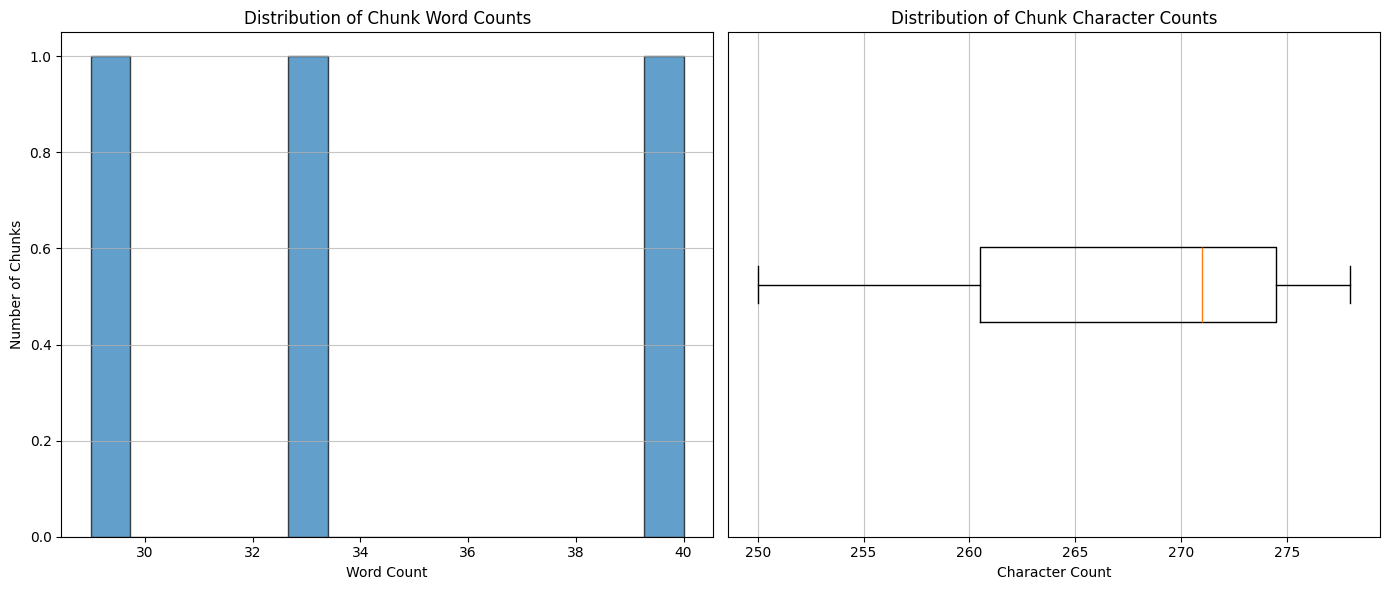

In [14]:
import matplotlib.pyplot as plt
from datetime import datetime

class ChunkingSystem:
    """
    Flexible chunking system for RAG preparation.
    """

    def __init__(self, strategy: str = 'smart'):
        self.strategy = strategy
        self.chunks = []

    def chunk(self, text: str, **kwargs) -> List[Dict[str, any]]:
        """
        Chunk text using selected strategy.
        """
        strategy = ['sentence', 'word', 'paragraph', 'smart']
        if self.strategy not in strategy:
            raise ValueError
        elif self.strategy == 'sentence':
            self.chunks = chunk_by_sentences(text, **kwargs)
        elif self.strategy == 'word':
            self.chunks = chunk_by_words(text, **kwargs)
        elif self.strategy == 'paragraph':
            self.chunks = chunk_by_paragraphs(text, **kwargs)
        elif self.strategy == 'smart':
            self.chunks = smart_chunk(text, **kwargs)
        return self.chunks

    def add_metadata(self, chunks: List[Dict], source: str = None) -> List[Dict]:
        """
        Add metadata to chunks.
        """
        timestamp = datetime.now().isoformat()
        for i, chunk in enumerate(chunks):
            chunk['metadata'] = {
                'position': i,
                'source': source,
                'timestamp': timestamp
            }
        return chunks

    def validate_chunks(self, chunks: List[Dict], min_words: int = 10, max_words: int = 200) -> Dict[str, any]:
        """
        Validate chunk quality.
        Checks for:
        1. Chunks not ending with punctuation (potential orphaned sentences).
        2. Chunks being too short or too long.
        """
        validation_results = {
            'total_chunks': len(chunks),
            'issues_found': False,
            'orphaned_sentence_ends': [],
            'size_warnings': []
        }

        sentence_enders = ['.', '?', '!', '"', '\''] # Common sentence ending punctuation

        for i, chunk_data in enumerate(chunks):
            chunk_text = chunk_data.get('text', '')
            if not chunk_text:
                continue

            # Check for orphaned sentences (chunk doesn't end with punctuation)
            if not chunk_text.strip().endswith(tuple(sentence_enders)):
                validation_results['issues_found'] = True
                validation_results['orphaned_sentence_ends'].append({
                    'chunk_index': i,
                    'last_chars': chunk_text.strip()[-20:]
                })

            # Check chunk size
            word_count = len(chunk_text.split())
            if word_count < min_words or word_count > max_words:
                validation_results['issues_found'] = True
                validation_results['size_warnings'].append({
                    'chunk_index': i,
                    'word_count': word_count,
                    'expected_range': f'{min_words}-{max_words}'
                })

        return validation_results

    def visualize_distribution(self, chunks: List[Dict]):
        """
        Visualize chunk size distribution.
        Plots a histogram of word counts and a box plot of character counts.
        """
        if not chunks:
            print("No chunks to visualize.")
            return

        word_counts = [chunk.get('word_count', len(chunk.get('text', '').split())) for chunk in chunks]
        char_counts = [chunk.get('char_count', len(chunk.get('text', ''))) for chunk in chunks]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot 1: Histogram of Word Counts
        axes[0].hist(word_counts, bins=15, edgecolor='black', alpha=0.7)
        axes[0].set_title('Distribution of Chunk Word Counts')
        axes[0].set_xlabel('Word Count')
        axes[0].set_ylabel('Number of Chunks')
        axes[0].grid(axis='y', alpha=0.75)

        # Plot 2: Box Plot of Character Counts
        axes[1].boxplot(char_counts, vert=False)
        axes[1].set_title('Distribution of Chunk Character Counts')
        axes[1].set_xlabel('Character Count')
        axes[1].set_yticks([]) # Hide y-axis ticks for box plot
        axes[1].grid(axis='x', alpha=0.75)

        plt.tight_layout()
        plt.show()

# Test your system
chunker = ChunkingSystem(strategy='smart')
text = """
A digital twin is a virtual representation of a physical object or system.
Digital twins are used across various industries. In healthcare, they model patient health.
In manufacturing, they simulate production processes. Smart cities use digital twins for urban planning.

The technology relies on real-time data from sensors. This data feeds into simulation models.
Machine learning algorithms analyze patterns. Predictions help optimize operations.

Benefits include improved decision-making. Companies reduce costs through predictive maintenance.
Healthcare providers personalize treatments. City planners optimize resource allocation.
"""

print("\n--- Testing ChunkingSystem ---")

# 1. Chunk the text
chunks = chunker.chunk(text, max_chunk_size=50, overlap=10)
print(f"Original text chunked into {len(chunks)} chunks.")

# 2. Add metadata
chunks_with_metadata = chunker.add_metadata(chunks, source="digital_twin_doc_1")
print(f"Metadata added to {len(chunks_with_metadata)} chunks. Sample metadata: {chunks_with_metadata[0].get('metadata')}")

# 3. Validate chunks
validation_results = chunker.validate_chunks(chunks_with_metadata)
print("\n--- Validation Results ---")
print(f"Total chunks: {validation_results['total_chunks']}")
print(f"Issues found: {validation_results['issues_found']}")
if validation_results['issues_found']:
    if validation_results['orphaned_sentence_ends']:
        print(f"  Orphaned sentence ends: {len(validation_results['orphaned_sentence_ends'])} issues")
    if validation_results['size_warnings']:
        print(f"  Size warnings: {len(validation_results['size_warnings'])} issues")

# 4. Visualize distribution
print("\n--- Visualizing Chunk Distribution ---")
chunker.visualize_distribution(chunks_with_metadata)

---
## Part 4: Real-World Text Processing Pipelines

Putting it all together for production systems.

### 4.1 Complete Processing Pipeline

In [15]:
class TextProcessor:
    """
    Complete text processing pipeline for digital twin.
    """

    def __init__(self):
        self.processing_history = []

    def process(self, text: str,
                clean: bool = True,
                extract_data: bool = True,
                chunk: bool = False,
                chunk_size: int = 100) -> Dict[str, any]:
        """
        Process text through complete pipeline.

        Args:
            text: Input text
            clean: Apply cleaning
            extract_data: Extract structured data
            chunk: Chunk the text
            chunk_size: Size for chunking

        Returns:
            dict: Processed results
        """
        result = {
            'original': text,
            'original_stats': self._get_stats(text),
            'processed': text,
            'extracted_data': {},
            'chunks': [],
            'pipeline_steps': []
        }

        # Step 1: Clean
        if clean:
            result['processed'] = self._clean(result['processed'])
            result['pipeline_steps'].append('cleaned')

        # Step 2: Extract structured data
        if extract_data:
            result['extracted_data'] = self._extract(result['processed'])
            result['pipeline_steps'].append('extracted')

        # Step 3: Chunk
        if chunk:
            result['chunks'] = self._chunk(result['processed'], chunk_size)
            result['pipeline_steps'].append('chunked')

        result['processed_stats'] = self._get_stats(result['processed'])

        self.processing_history.append(result)
        return result

    def _clean(self, text: str) -> str:
        """Clean text."""
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()
        return text

    def _extract(self, text: str) -> Dict[str, any]:
        """Extract structured data."""
        data = {}
        for pattern_name, pattern in PATTERNS.items():
            matches = re.findall(pattern, text, re.IGNORECASE)
            if matches:
                data[pattern_name] = matches
        return data

    def _chunk(self, text: str, chunk_size: int) -> List[Dict]:
        """Chunk text."""
        return smart_chunk(text, max_chunk_size=chunk_size)

    def _get_stats(self, text: str) -> Dict[str, int]:
        """Get text statistics."""
        return {
            'chars': len(text),
            'words': len(text.split()),
            'lines': len(text.split('\n')),
        }

# Test the complete pipeline
processor = TextProcessor()

sample_text = """
Hi! I'm Alex (alex@email.com). I love running and have been tracking my progress.
Yesterday I ran 5km in 28 minutes at 6:30am. My goal is to complete a marathon (42km) by 2026-06-15.

I also enjoy coding in Python and building ML models. Check out my GitHub: https://github.com/alexruns

Daily routine:
- Wake up at 5:45am
- Run for 45-60min
- Work from 9:00am to 5:00pm
- Code on side projects from 8:00pm to 10:00pm

#running #fitness #coding #python #AI
"""

result = processor.process(
    sample_text,
    clean=True,
    extract_data=True,
    chunk=True,
    chunk_size=50
)

print("Processing Results:")
print(f"Pipeline steps: {result['pipeline_steps']}")
print(f"\nOriginal stats: {result['original_stats']}")
print(f"Processed stats: {result['processed_stats']}")
print(f"\nExtracted data:")
for key, values in result['extracted_data'].items():
    print(f"  {key}: {values}")
print(f"\nChunks created: {len(result['chunks'])}")

Processing Results:
Pipeline steps: ['cleaned', 'extracted', 'chunked']

Original stats: {'chars': 458, 'words': 78, 'lines': 14}
Processed stats: {'chars': 453, 'words': 78, 'lines': 1}

Extracted data:
  email: ['alex@email.com']
  date: ['2026-06-15']
  time: ['6:30am', '5:45am', '9:00am', '5:00pm', '8:00pm', '10:00pm']
  url: ['https://github.com/alexruns']
  hashtag: ['#running', '#fitness', '#coding', '#python', '#AI']
  mention: ['@email']
  number: ['28', '6', '2026', '06', '15', '5', '45', '9', '5', '8', '10']
  duration: ['60m']

Chunks created: 1


---
## Summary & Key Takeaways

### What We Learned:

1. **String Basics**: Slicing, indexing, and essential methods
2. **Regex Power**: Pattern matching for complex data extraction
3. **Chunking Strategies**: Preparing text for RAG systems
4. **Production Pipelines**: Building robust text processors

### Why This Matters for RAG:
- **Debugging**: Can't debug what you can't parse
- **Quality**: Good chunks = better retrieval
- **Efficiency**: Proper preprocessing saves tokens and costs
- **Robustness**: Handle messy real-world text

### Next Steps:
In the next notebook, we'll explore:
- Context windows and token limits
- Managing long documents
- Context compression techniques

## 🏆 Challenge Project

**Build a Document Preprocessor for Digital Twin Knowledge Base**

Create a complete system that:
1. Ingests documents in multiple formats (text, markdown, logs)
2. Extracts all relevant structured data
3. Cleans and normalizes text
4. Chunks optimally for RAG
5. Generates metadata for each chunk
6. Creates search indices
7. Provides quality metrics

**Bonus**: Add support for handling tables, code blocks, and special formatting!